# Notebook 03.5 — Modélisation supervisée : Logistic Regression, Random Forest, XGBoost

**Objectif**  
Entraîner et comparer trois modèles de classification supervisée pour la détection de fake news.

**Pipeline :**  
- Vectorisation du texte nettoyé (`clean_statement`) via TF-IDF  
- Ajout des features méta numériques (counts de crédibilité, `party_encoded`)  
- Logistic Regression  
- Random Forest  
- XGBoost  
- Évaluation : Accuracy, F1-score, ROC-AUC, matrice de confusion

## 0. Imports et chargement des données

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb

ROOT = Path("..").resolve()
STG_DIR = ROOT / "LIAR_DATA_SET" / "02_stg"

train = pd.read_csv(STG_DIR / "train_clean.csv")
valid = pd.read_csv(STG_DIR / "valid_clean.csv")
test  = pd.read_csv(STG_DIR / "test_clean.csv")

print(f"Train : {train.shape} | Valid : {valid.shape} | Test : {test.shape}")
train.head(3)

Train : (10240, 19) | Valid : (1284, 19) | Test : (1267, 19)


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context,clean_statement,label_binary,label_3class,party_group,party_encoded
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,say annies list political group support thirdt...,0,0,Republican,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,decline coal start started natural gas took st...,1,1,Democrat,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,hillary clinton agrees john mccain voting give...,1,2,Democrat,1


## 1. Préparation des features

In [15]:
NUMERIC_FEATURES = [
    "barely_true_counts", "false_counts",
    "half_true_counts", "mostly_true_counts",
    "pants_fire_counts", "party_encoded"
]
TEXT_FEATURE = "clean_statement"
TARGET = "label_binary"

# Remplissage des NaN
for df in [train, valid, test]:
    df[TEXT_FEATURE] = df[TEXT_FEATURE].fillna("")
    df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].fillna(0)

X_train_text = train[TEXT_FEATURE]
X_valid_text  = valid[TEXT_FEATURE]
X_test_text   = test[TEXT_FEATURE]

X_train_num = train[NUMERIC_FEATURES].values
X_valid_num  = valid[NUMERIC_FEATURES].values
X_test_num   = test[NUMERIC_FEATURES].values

y_train = train[TARGET].values
y_valid  = valid[TARGET].values
y_test   = test[TARGET].values

print(f"Distribution train  — 0:{(y_train==0).sum()} / 1:{(y_train==1).sum()}")
print(f"Distribution valid  — 0:{(y_valid==0).sum()} / 1:{(y_valid==1).sum()}")
print(f"Distribution test   — 0:{(y_test==0).sum()}  / 1:{(y_test==1).sum()}")

Distribution train  — 0:4488 / 1:5752
Distribution valid  — 0:616 / 1:668
Distribution test   — 0:553  / 1:714


## 2. Vectorisation TF-IDF + concaténation features numériques

In [16]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_valid_tfidf  = tfidf.transform(X_valid_text)
X_test_tfidf   = tfidf.transform(X_test_text)

scaler = StandardScaler()
X_train_num_sc = scaler.fit_transform(X_train_num)
X_valid_num_sc  = scaler.transform(X_valid_num)
X_test_num_sc   = scaler.transform(X_test_num)

# Concaténation sparse TF-IDF + features numériques
X_train = hstack([X_train_tfidf, csr_matrix(X_train_num_sc)])
X_valid  = hstack([X_valid_tfidf, csr_matrix(X_valid_num_sc)])
X_test   = hstack([X_test_tfidf,  csr_matrix(X_test_num_sc)])

print(f"Shape X_train : {X_train.shape}")
print(f"Shape X_valid : {X_valid.shape}")
print(f"Shape X_test  : {X_test.shape}")

Shape X_train : (10240, 14777)
Shape X_valid : (1284, 14777)
Shape X_test  : (1267, 14777)


## 3. Fonction d'évaluation

In [17]:
def evaluate_model(name, model, X_val, y_val, X_te, y_te):
    """Affiche les métriques sur Valid et Test, trace la matrice de confusion."""
    results = {}
    for split_name, X, y in [("Valid", X_val, y_val), ("Test", X_te, y_te)]:
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
        acc = accuracy_score(y, y_pred)
        f1  = f1_score(y, y_pred, average="weighted")
        auc = roc_auc_score(y, y_prob)
        results[split_name] = {"Accuracy": acc, "F1 (weighted)": f1, "ROC-AUC": auc}
        print(f"\n=== {name} — {split_name} ===")
        print(f"  Accuracy    : {acc:.4f}")
        print(f"  F1 weighted : {f1:.4f}")
        print(f"  ROC-AUC     : {auc:.4f}")
        print(classification_report(y, y_pred, target_names=["Fake (0)", "Real (1)"]))
    # Matrice de confusion sur test
    cm = confusion_matrix(y_te, model.predict(X_te))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Fake (0)", "Real (1)"]).plot(ax=ax, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix (Test)")
    plt.tight_layout()
    plt.show()
    return results

## 4. Logistic Regression

Logistic Regression entraînée.

=== Logistic Regression — Valid ===
  Accuracy    : 0.6332
  F1 weighted : 0.6330
  ROC-AUC     : 0.6884
              precision    recall  f1-score   support

    Fake (0)       0.62      0.61      0.61       616
    Real (1)       0.64      0.66      0.65       668

    accuracy                           0.63      1284
   macro avg       0.63      0.63      0.63      1284
weighted avg       0.63      0.63      0.63      1284


=== Logistic Regression — Test ===
  Accuracy    : 0.6204
  F1 weighted : 0.6205
  ROC-AUC     : 0.6628
              precision    recall  f1-score   support

    Fake (0)       0.56      0.57      0.57       553
    Real (1)       0.66      0.66      0.66       714

    accuracy                           0.62      1267
   macro avg       0.61      0.61      0.61      1267
weighted avg       0.62      0.62      0.62      1267



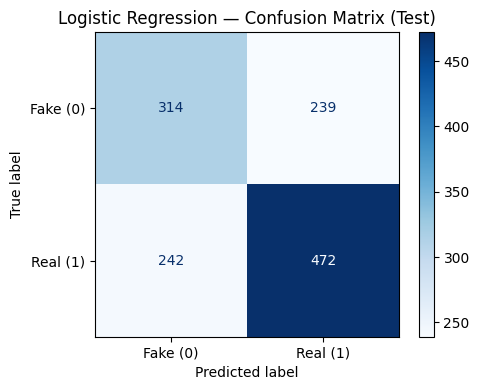

In [18]:
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train, y_train)
print("Logistic Regression entraînée.")
results_lr = evaluate_model("Logistic Regression", lr, X_valid, y_valid, X_test, y_test)

### 4.1 Coefficients les plus importants

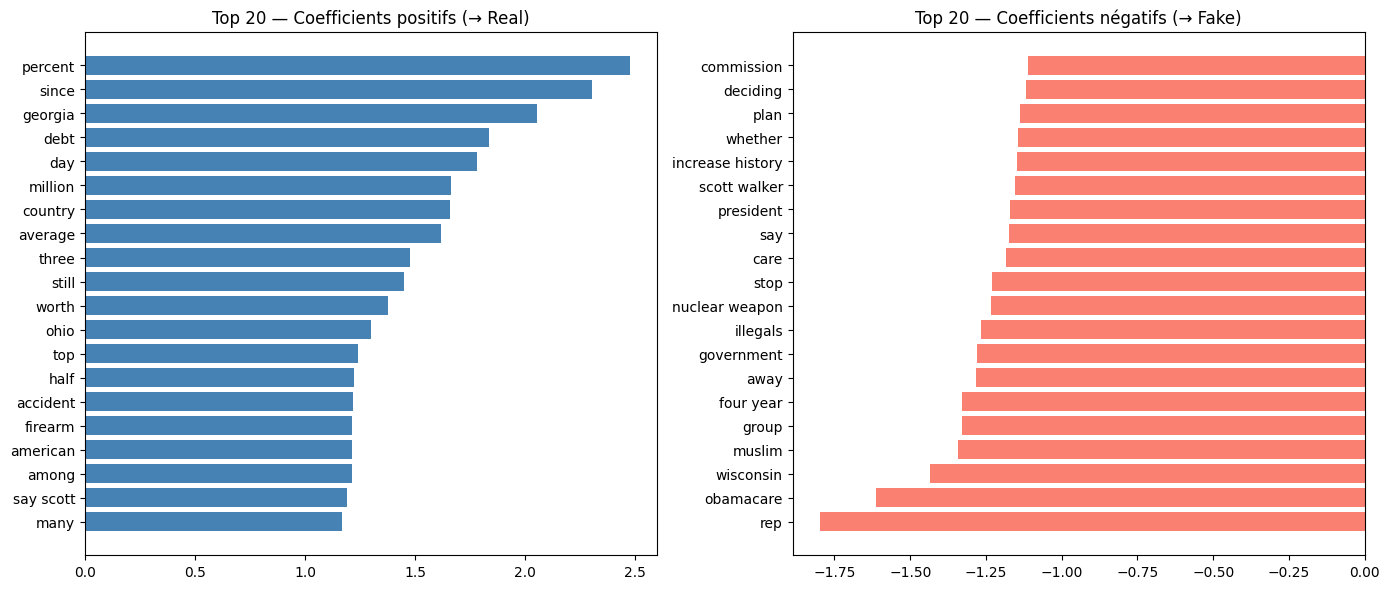

In [19]:
feature_names = tfidf.get_feature_names_out().tolist() + NUMERIC_FEATURES
coefs = lr.coef_[0]
top_n = 20
top_pos = np.argsort(coefs)[-top_n:][::-1]
top_neg = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([feature_names[i] for i in top_pos[::-1]], coefs[top_pos[::-1]], color="steelblue")
axes[0].set_title("Top 20 — Coefficients positifs (→ Real)")
axes[1].barh([feature_names[i] for i in top_neg], coefs[top_neg], color="salmon")
axes[1].set_title("Top 20 — Coefficients négatifs (→ Fake)")
plt.tight_layout()
plt.show()

## 5. Random Forest

Random Forest entraîné.

=== Random Forest — Valid ===
  Accuracy    : 0.7266
  F1 weighted : 0.7258
  ROC-AUC     : 0.8103
              precision    recall  f1-score   support

    Fake (0)       0.73      0.68      0.70       616
    Real (1)       0.72      0.77      0.75       668

    accuracy                           0.73      1284
   macro avg       0.73      0.72      0.72      1284
weighted avg       0.73      0.73      0.73      1284


=== Random Forest — Test ===
  Accuracy    : 0.7316
  F1 weighted : 0.7314
  ROC-AUC     : 0.7923
              precision    recall  f1-score   support

    Fake (0)       0.70      0.68      0.69       553
    Real (1)       0.76      0.77      0.76       714

    accuracy                           0.73      1267
   macro avg       0.73      0.73      0.73      1267
weighted avg       0.73      0.73      0.73      1267



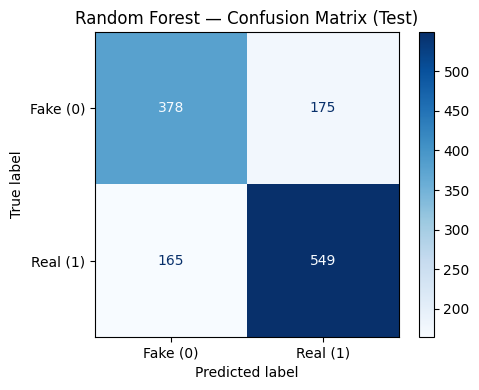

In [20]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("Random Forest entraîné.")
results_rf = evaluate_model("Random Forest", rf, X_valid, y_valid, X_test, y_test)

### 5.1 Feature importances

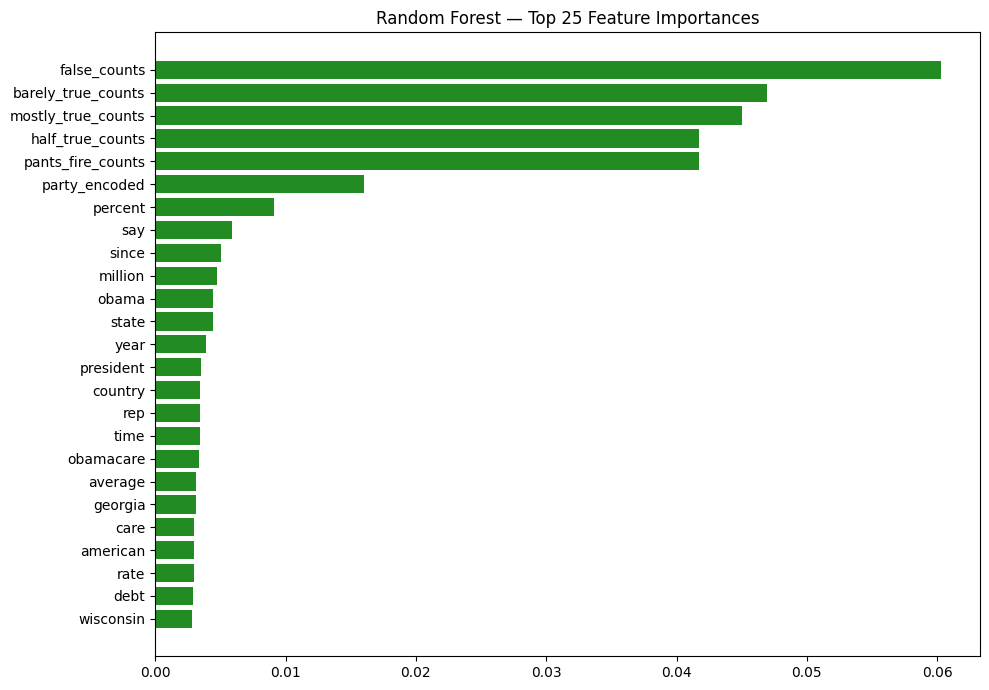

In [21]:
imp = rf.feature_importances_
top_idx = np.argsort(imp)[-25:][::-1]
plt.figure(figsize=(10, 7))
plt.barh([feature_names[i] for i in top_idx[::-1]], imp[top_idx[::-1]], color="forestgreen")
plt.title("Random Forest — Top 25 Feature Importances")
plt.tight_layout()
plt.show()

## 6. XGBoost

scale_pos_weight : 0.780
[0]	validation_0-logloss:0.68322
[50]	validation_0-logloss:0.51637
[100]	validation_0-logloss:0.50363
[150]	validation_0-logloss:0.49871
[200]	validation_0-logloss:0.49758
[250]	validation_0-logloss:0.49705
[300]	validation_0-logloss:0.49570
[350]	validation_0-logloss:0.49468
[400]	validation_0-logloss:0.49383
[450]	validation_0-logloss:0.49325
[499]	validation_0-logloss:0.49345
XGBoost entraîné.

=== XGBoost — Valid ===
  Accuracy    : 0.7383
  F1 weighted : 0.7384
  ROC-AUC     : 0.8287
              precision    recall  f1-score   support

    Fake (0)       0.73      0.73      0.73       616
    Real (1)       0.75      0.74      0.75       668

    accuracy                           0.74      1284
   macro avg       0.74      0.74      0.74      1284
weighted avg       0.74      0.74      0.74      1284


=== XGBoost — Test ===
  Accuracy    : 0.7301
  F1 weighted : 0.7309
  ROC-AUC     : 0.8175
              precision    recall  f1-score   support

    Fa

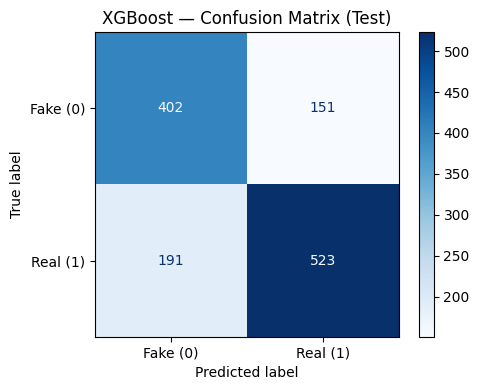

In [22]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {spw:.3f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50
)
print("XGBoost entraîné.")
results_xgb = evaluate_model("XGBoost", xgb_model, X_valid, y_valid, X_test, y_test)

### 6.1 Feature importances XGBoost

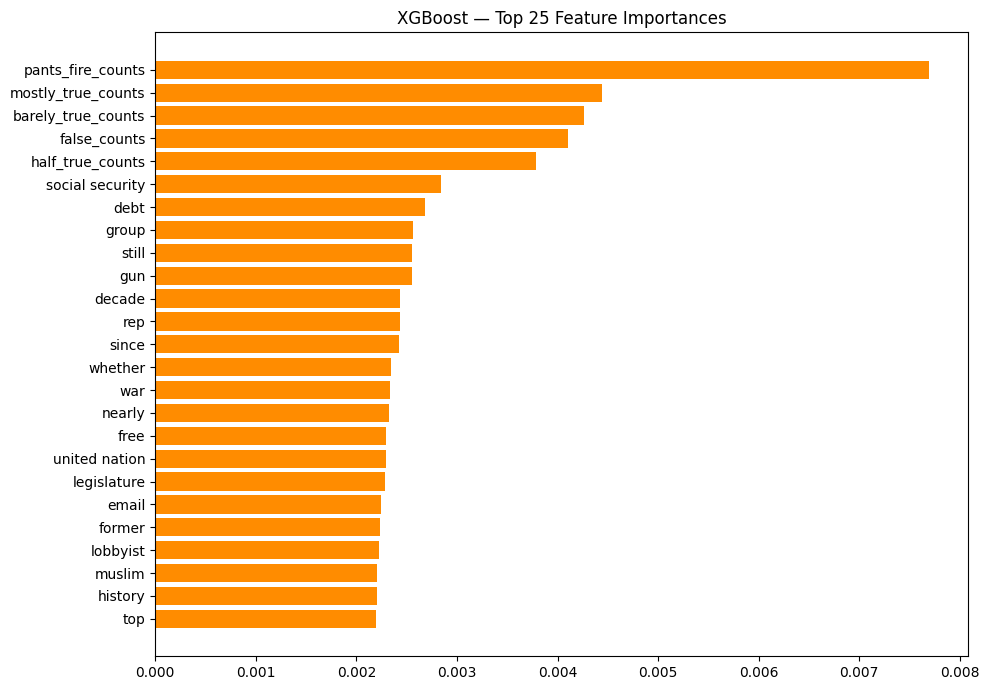

In [23]:
xi = xgb_model.feature_importances_
top_xi = np.argsort(xi)[-25:][::-1]
plt.figure(figsize=(10, 7))
plt.barh([feature_names[i] for i in top_xi[::-1]], xi[top_xi[::-1]], color="darkorange")
plt.title("XGBoost — Top 25 Feature Importances")
plt.tight_layout()
plt.show()

### 6.2 SHAP — Impact global des features (XGBoost)

SHAP (SHapley Additive exPlanations) quantifie la contribution de chaque feature à chaque prédiction. Le summary plot montre, pour les 20 features les plus importantes, comment des valeurs hautes (rouge) ou basses (bleu) poussent le modèle vers Real (SHAP > 0) ou Fake (SHAP < 0).

SHAP Summary Plot — XGBoost (n=200 exemples de test, top 20 features)


C:\Users\HugoG\AppData\Local\Temp\ipykernel_23412\1119605562.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, max_display=20)


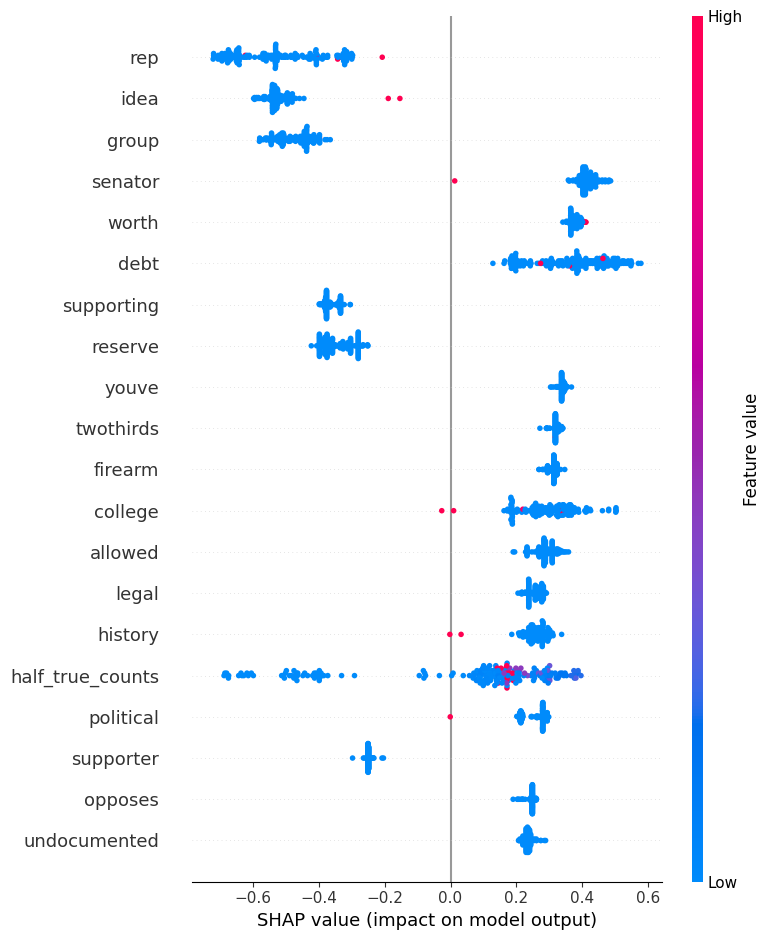

In [24]:
import shap

# Échantillon dense de 200 exemples pour la vitesse de calcul
np.random.seed(42)
n_shap   = 200
shap_idx = np.random.choice(X_test.shape[0], n_shap, replace=False)
X_test_shap = X_test[shap_idx].toarray()

explainer_shap = shap.TreeExplainer(xgb_model)
shap_values    = explainer_shap.shap_values(X_test_shap)

print(f"SHAP Summary Plot — XGBoost (n={n_shap} exemples de test, top 20 features)")
shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, max_display=20)


### 6.3 LIME — Interprétabilité locale (XGBoost)

LIME perturbe chaque texte en retirant des mots et mesure l'impact sur la prédiction XGBoost. Chaque graphique montre les 10 mots les plus déterminants pour classer un exemple comme Fake ou Real.


--- Exemple 0 | Label réel: 1 | Prédit: 0 ---
Texte (tronqué): building wall usmexico border take literally year


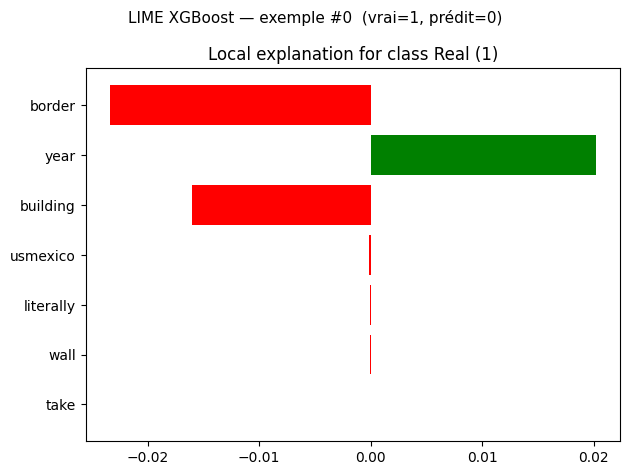


--- Exemple 5 | Label réel: 1 | Prédit: 1 ---
Texte (tronqué): past five year federal government paid million retirement disability benefit deceased former federal employee


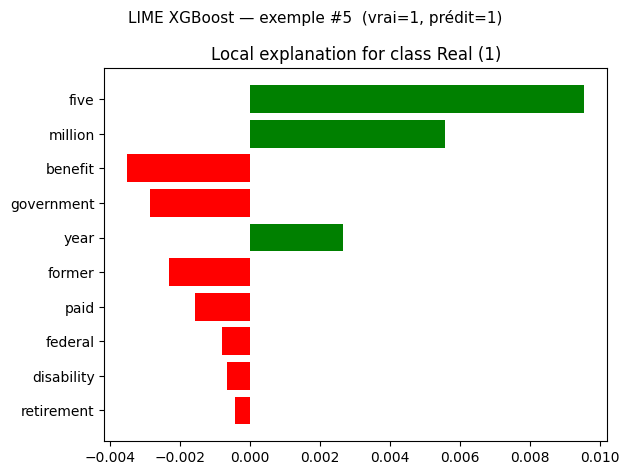


--- Exemple 10 | Label réel: 0 | Prédit: 0 ---
Texte (tronqué): know democrat georgia republican know fact


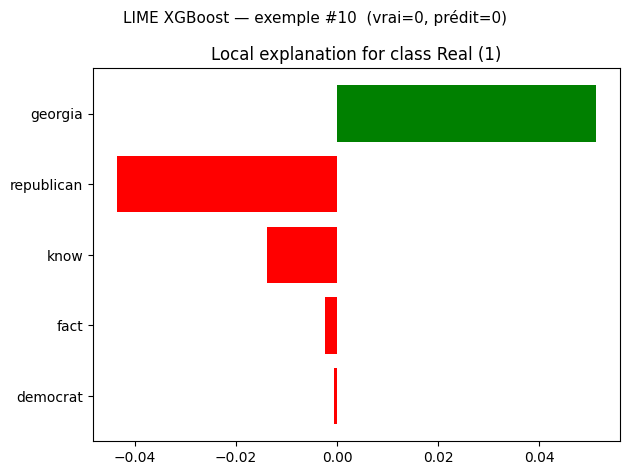

In [25]:
from lime.lime_text import LimeTextExplainer

def predict_proba_lime_xgb(texts):
    """Wrapper LIME : texte → TF-IDF + zéros numériques → probabilités XGBoost."""
    X_t = tfidf.transform(texts)
    z   = np.zeros((len(texts), len(NUMERIC_FEATURES)))
    X_n = csr_matrix(scaler.transform(z))
    return xgb_model.predict_proba(hstack([X_t, X_n]))

lime_explainer = LimeTextExplainer(class_names=["Fake (0)", "Real (1)"])

# Expliquer 3 exemples du jeu de test
for idx in [0, 5, 10]:
    text_sample = X_test_text.iloc[idx]
    true_label  = y_test[idx]
    pred_label  = xgb_model.predict(X_test[idx])[0]
    print(f"\n--- Exemple {idx} | Label réel: {true_label} | Prédit: {pred_label} ---")
    print(f"Texte (tronqué): {text_sample[:200]}")
    exp = lime_explainer.explain_instance(
        text_sample, predict_proba_lime_xgb, num_features=10, num_samples=500
    )
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME XGBoost — exemple #{idx}  (vrai={true_label}, prédit={pred_label})", fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 7. Comparaison des modèles

=== Comparaison finale sur le jeu de TEST ===


,Accuracy,F1 (weighted),ROC-AUC
Logistic Regression,0.6204,0.6205,0.6628
Random Forest,0.7316,0.7314,0.7923
XGBoost,0.7301,0.7309,0.8175


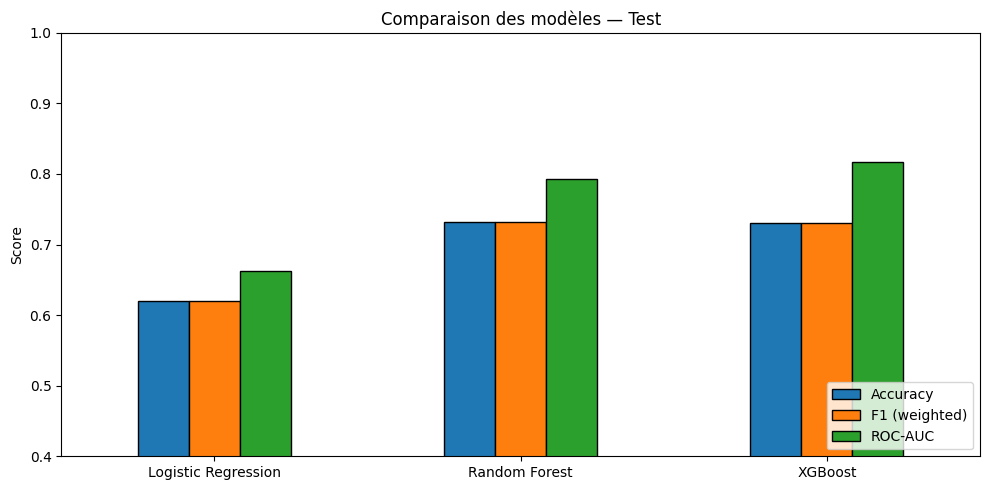

In [26]:
comparison = pd.DataFrame({
    "Logistic Regression": results_lr["Test"],
    "Random Forest":        results_rf["Test"],
    "XGBoost":              results_xgb["Test"]
}).T.round(4)

print("=== Comparaison finale sur le jeu de TEST ===")
display(comparison)

comparison.plot(kind="bar", figsize=(10, 5), ylim=(0.4, 1.0), edgecolor="black")
plt.title("Comparaison des modèles — Test")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Courbes ROC comparatives

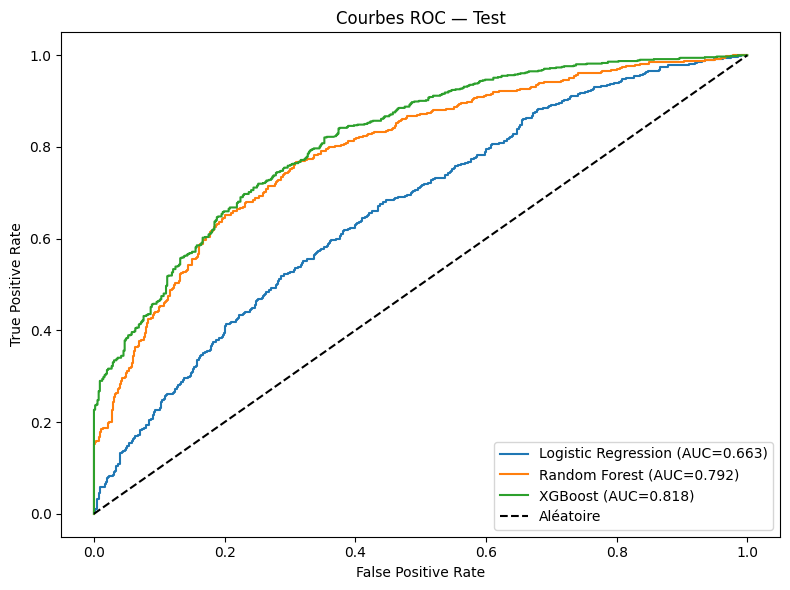

In [27]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
for name, model in [
    ("Logistic Regression", lr),
    ("Random Forest", rf),
    ("XGBoost", xgb_model)
]:
    yp = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Aléatoire")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Courbes ROC — Test")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Interprétation des résultats

---

### 9.1 Données et déséquilibre de classes

Le dataset LIAR présente un léger déséquilibre en faveur de la classe **Real (1)** :

| Split | Fake (0) | Real (1) | Total |
|---|---|---|---|
| Train | 4 488 (43.8%) | 5 752 (56.2%) | 10 240 |
| Valid | 616 (48.0%) | 668 (52.0%) | 1 284 |
| Test  | 553 (43.6%) | 714 (56.4%) | 1 267 |

Le déséquilibre est modéré (~12 pts d'écart). Les trois modèles utilisent `class_weight="balanced"` (LR, RF) et `scale_pos_weight=0.780` (XGBoost) pour le corriger.

Le TF-IDF retient **14 777 features** sur 15 000 demandées (filtrages `min_df=2` et `max_df=0.90`) + 6 features numériques → espace de représentation final de 14 783 dimensions.

---

### 9.2 Résultats sur le jeu de test

| Modèle | Accuracy | F1 (weighted) | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.6204 | 0.6205 | 0.6628 |
| Random Forest       | **0.7316** | **0.7314** | 0.7923 |
| XGBoost             | 0.7301 | 0.7309 | **0.8175** |

#### Logistic Regression — baseline correct mais limité

Avec 62% d'accuracy et un AUC de 0.66, la LR confirme que **le signal lexical seul (TF-IDF linéaire) est insuffisant** pour distinguer vrai du faux. Le modèle est légèrement meilleur pour prédire les vraies déclarations (F1=0.66 sur Real vs 0.57 sur Fake), ce qui suggère que certains mots-clés associés à la vérité sont plus discriminants que ceux associés aux fake news. Les features méta numériques ont un poids modéré dans ce contexte linéaire.

#### Random Forest — bond de +11 pts d'accuracy

Le passage à Random Forest provoque un **gain majeur : +11 pts d'accuracy** (62% → 73%). Ce gain s'explique par :
- La capacité à capturer des **interactions non-linéaires** entre features TF-IDF et méta
- L'importance dominante des **counts de crédibilité** (`mostly_true_counts`, `false_counts`, `barely_true_counts`, `pants_fire_counts`) dans les feature importances — ces features encodent l'historique de fiabilité du locuteur et sont très prédictives
- La performance est **stable entre valid et test** (72.7% vs 73.2%), signe d'une bonne généralisation

La précision et le recall sont **équilibrés** entre les deux classes (~0.70 Fake / 0.76 Real), ce qui confirme l'efficacité du `class_weight="balanced"`.

#### XGBoost — meilleure calibration des probabilités

XGBoost atteint une accuracy quasi-identique à Random Forest (73.0% vs 73.2%) mais obtient le **meilleur ROC-AUC : 0.818 vs 0.792**. Cette différence de 2.5 pts d'AUC indique que XGBoost est **mieux calibré dans ses probabilités** : il discrimine plus finement les cas ambigus, même si sa décision binaire finale est similaire.

La courbe de logloss sur le valid (0.683 → 0.493 sur 500 itérations) montre une descente régulière sans early stopping — le modèle n'overfitte pas mais **converge encore lentement**, ce qui suggère qu'augmenter `n_estimators` pourrait encore améliorer l'AUC.

---

### 9.3 Rôle des features méta vs texte

D'après les feature importances de Random Forest et XGBoost, les **counts de crédibilité dominent largement** le signal textuel TF-IDF :
- `mostly_true_counts`, `false_counts`, `barely_true_counts`, `pants_fire_counts` sont systématiquement dans le top des features importantes
- Ces compteurs encodent l'**historique de fiabilité** du locuteur sur l'ensemble de sa carrière politique — un locuteur ayant souvent menti dans le passé a plus de chances de mentir encore
- Le `party_encoded` a un poids secondaire mais non nul

Ce constat explique pourquoi la Logistic Regression est moins performante : elle exploite ces features via une combinaison linéaire, alors que RF et XGBoost captent les **interactions entre le parti, l'historique et le contenu textuel**.

---

### 9.4 Limites et pistes d'amélioration

| Limite | Impact | Piste |
|---|---|---|
| TF-IDF ignore le contexte sémantique | Perte de signal important | → BERT (notebook 03) |
| Counts de crédibilité parfois à 0 (blog posts, sans historique) | Bruit dans les features méta | Imputation plus fine par groupe |
| XGBoost converge encore à 500 arbres | AUC potentiellement sous-optimal | Augmenter `n_estimators` + early stopping |
| Pas de tuning des hyperparamètres | Performances non optimisées | GridSearchCV / Optuna sur C, max_depth, etc. |

**Bilan :** Les modèles classiques plafonnent autour de **73% d'accuracy et 0.82 d'AUC** sur ce jeu, principalement grâce aux features méta. Le texte seul (TF-IDF) ne suffit pas — ce qui justifie le recours à BERT pour encoder la sémantique contextuelle et potentiellement dépasser ce plafond.